<h1>Analisis actividad 3: Lying down</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [2]:
actividad = 3

In [3]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [4]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [5]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Correlación entre los atributos</h1>

In [6]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.419780,0.408899,-0.012846,-0.071943,-0.226823,0.301304,0.622016,0.276178,0.446191,-0.306418,-0.034162,0.017646,0.044089,-0.351192,-0.154685,-0.009737,-0.107498,0.442670,0.457053,-0.023643,-0.018292,0.008996,-0.159066
chest_acc_y,0.419780,1.000000,0.929451,-0.002926,-0.039231,0.232808,0.340780,0.227079,-0.048488,-0.302452,0.007825,-0.156210,-0.056385,0.126181,-0.120666,0.237486,0.298997,-0.242850,0.420146,0.007167,-0.173801,-0.069551,0.102121,-0.853781
chest_acc_z,0.408899,0.929451,1.000000,0.012609,-0.016288,0.138005,0.304570,0.314403,-0.047627,-0.239088,0.096995,-0.188897,-0.033520,0.207222,0.028566,0.281121,0.528492,-0.070857,0.249665,0.125774,-0.121981,-0.061980,0.084624,-0.818550
ecg_1,-0.012846,-0.002926,0.012609,1.000000,0.956224,0.035643,0.032800,0.006664,0.028833,0.016683,-0.015981,-0.008610,-0.001423,0.021788,-0.011299,0.015227,0.026204,-0.005631,-0.018318,0.039269,0.002884,0.004250,-0.005493,0.002241
ecg_2,-0.071943,-0.039231,-0.016288,0.956224,1.000000,0.026877,0.016626,-0.007879,-0.011943,-0.024431,0.021205,0.009422,0.001488,-0.008821,0.037379,0.072946,0.036222,0.024561,-0.063460,0.012120,0.020832,0.022466,-0.007074,0.033680
ankle_acc_x,-0.226823,0.232808,0.138005,0.035643,0.026877,1.000000,0.554061,-0.340280,0.554849,-0.168315,-0.610214,-0.201720,-0.035032,0.249587,-0.592912,0.082758,-0.316808,-0.678135,0.150579,0.155136,-0.134512,-0.098644,0.031312,-0.007524
ankle_acc_y,0.301304,0.340780,0.304570,0.032800,0.016626,0.554061,1.000000,0.568257,0.414910,0.462612,-0.486375,-0.052374,-0.064728,0.050495,-0.774716,0.030009,-0.019992,-0.664232,0.493069,0.645052,0.073027,-0.021140,-0.072164,-0.216477
ankle_acc_z,0.622016,0.227079,0.314403,0.006664,-0.007879,-0.340280,0.568257,1.000000,-0.084723,0.622738,0.070878,0.046251,-0.039818,-0.049696,-0.271201,-0.014674,0.319009,-0.110336,0.455358,0.546895,0.191119,0.046801,-0.100723,-0.258195
ankle_gyro_x,0.276178,-0.048488,-0.047627,0.028833,-0.011943,0.554849,0.414910,-0.084723,1.000000,0.442822,-0.916449,-0.087272,0.074815,0.136486,-0.623700,-0.440252,-0.240442,-0.300797,-0.154328,0.668321,-0.065552,-0.054578,0.012361,0.330096
ankle_gyro_y,0.446191,-0.302452,-0.239088,0.016683,-0.024431,-0.168315,0.462612,0.622738,0.442822,1.000000,-0.373564,0.154150,0.037135,-0.133353,-0.475989,-0.435250,0.045523,-0.045260,0.092561,0.811974,0.195311,0.025162,-0.141554,0.224580


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

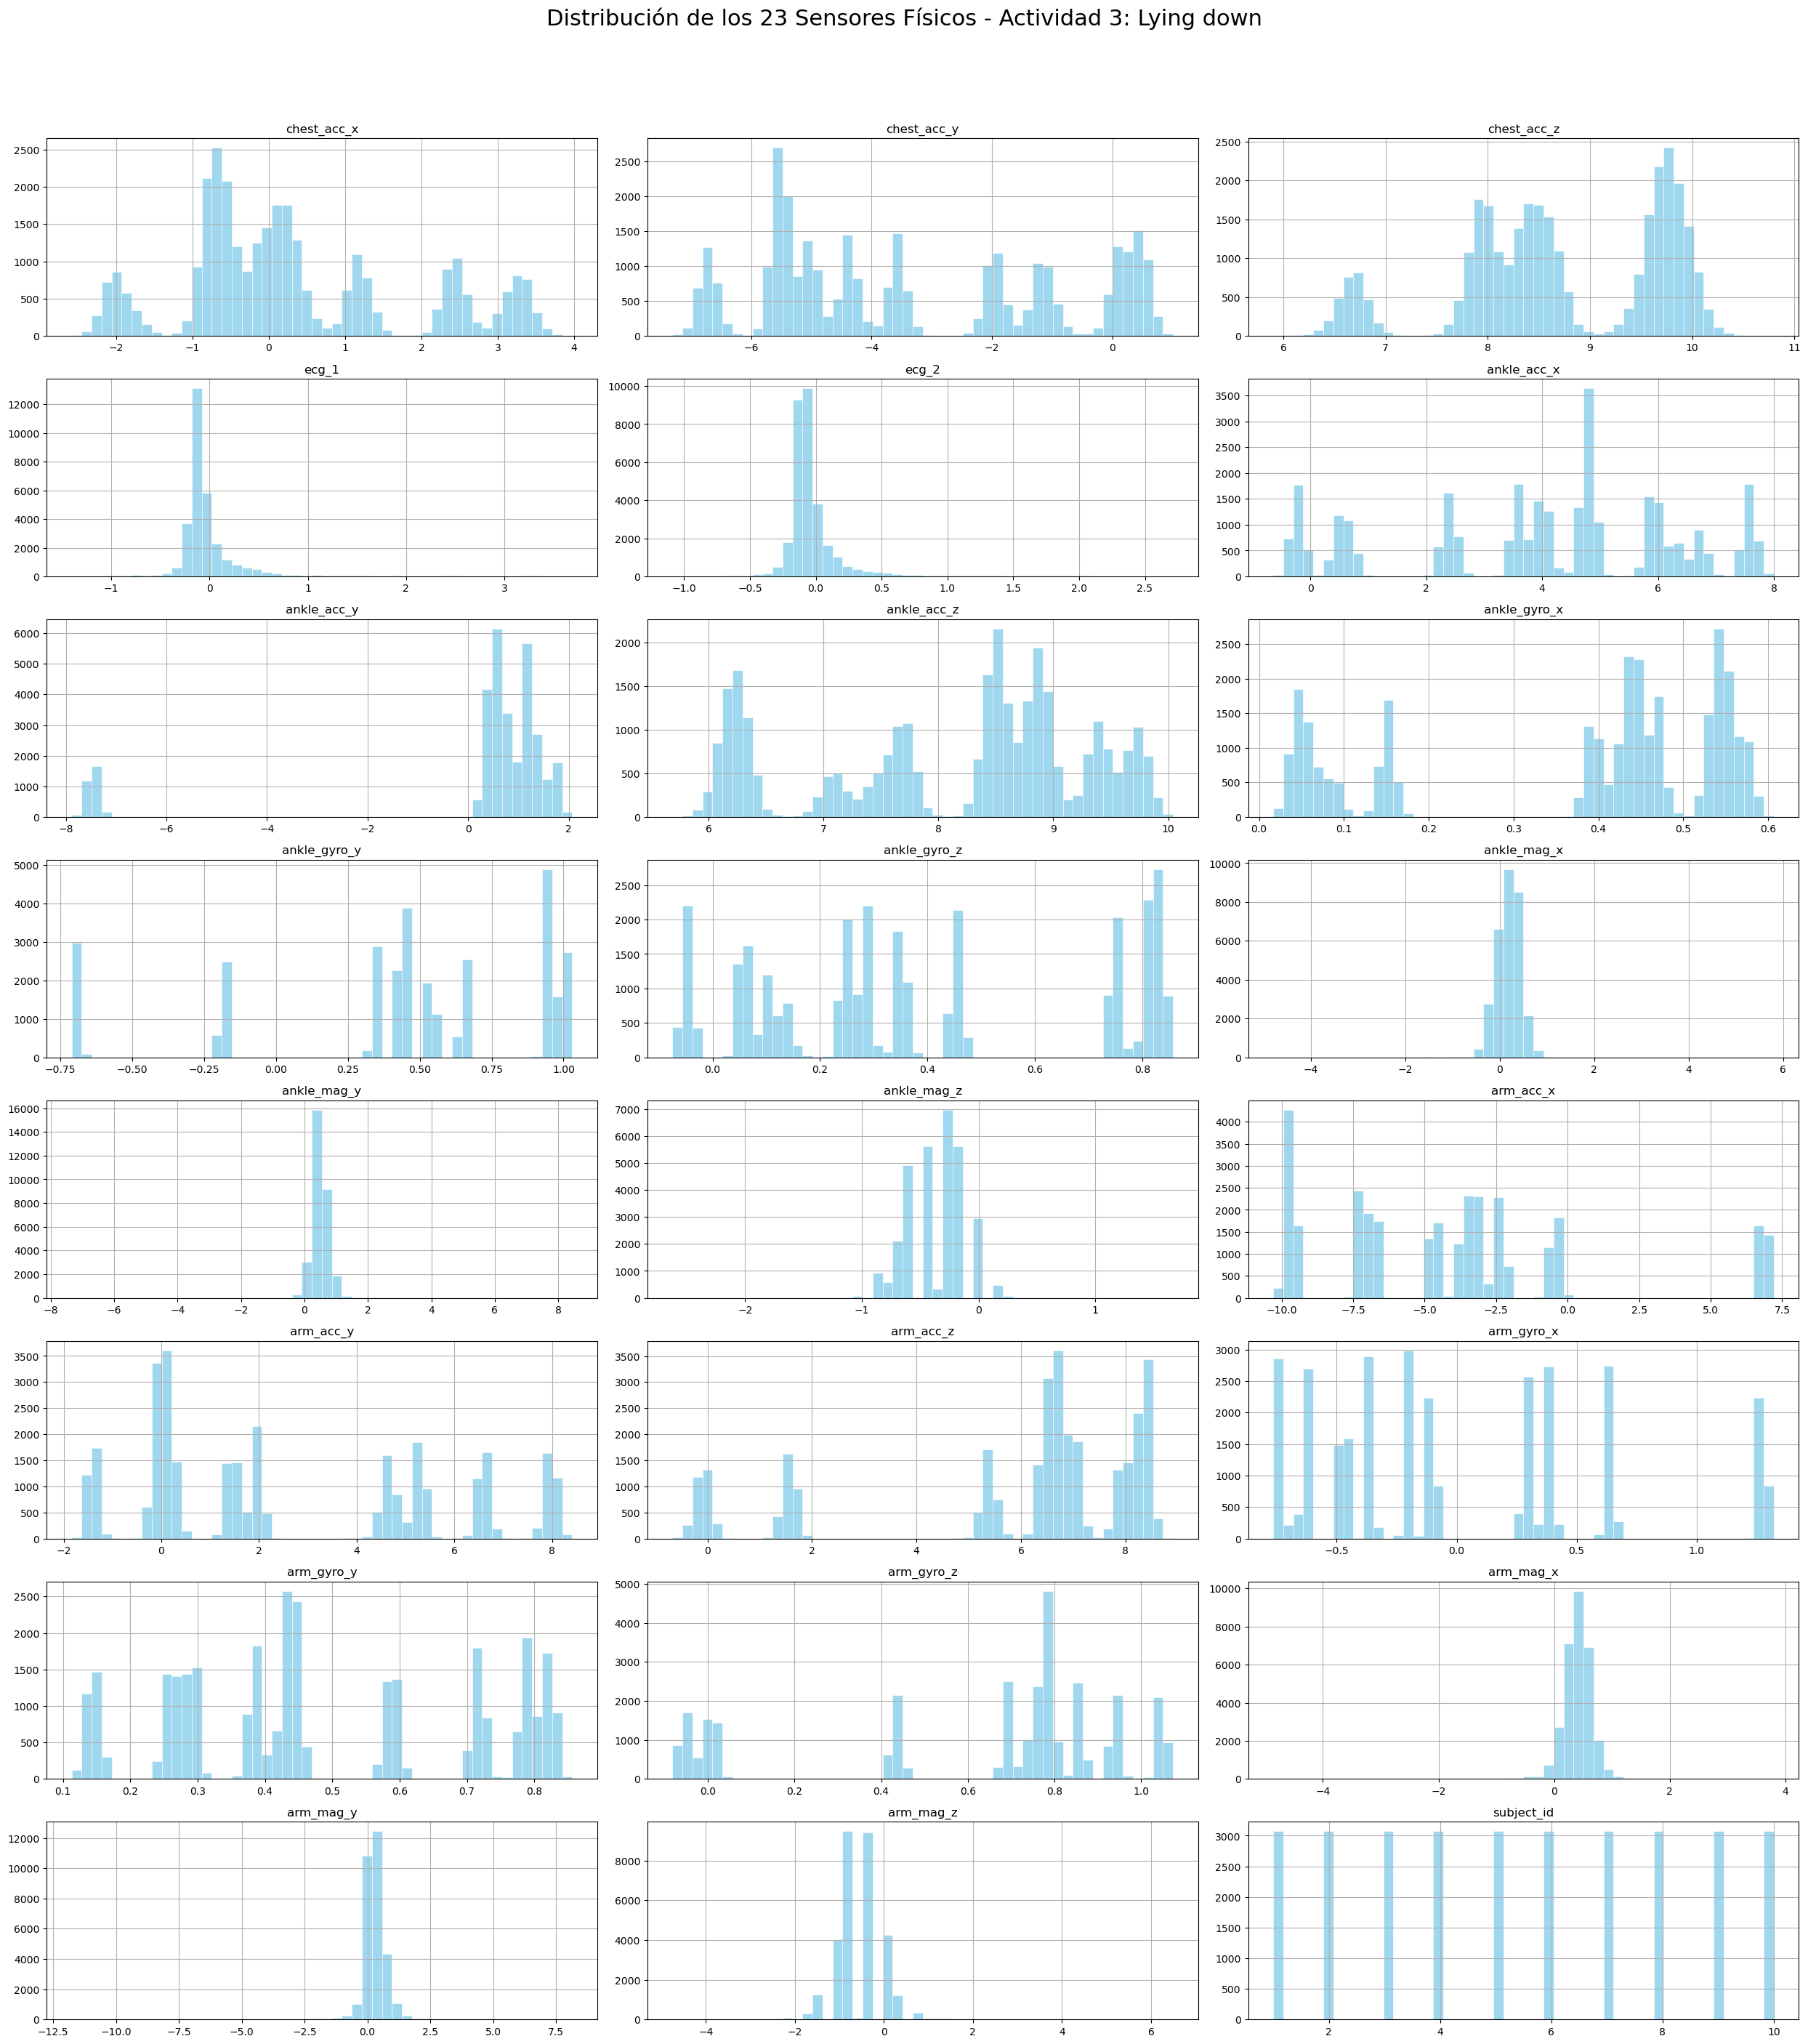

In [7]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [8]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,1,0.00
1,chest_acc_y,0,0.00
2,chest_acc_z,0,0.00
3,ecg_1,3872,12.60
4,ecg_2,3321,10.81
5,ankle_acc_x,0,0.00
6,ankle_acc_y,3072,10.00
7,ankle_acc_z,0,0.00
8,ankle_gyro_x,0,0.00
9,ankle_gyro_y,3072,10.00


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

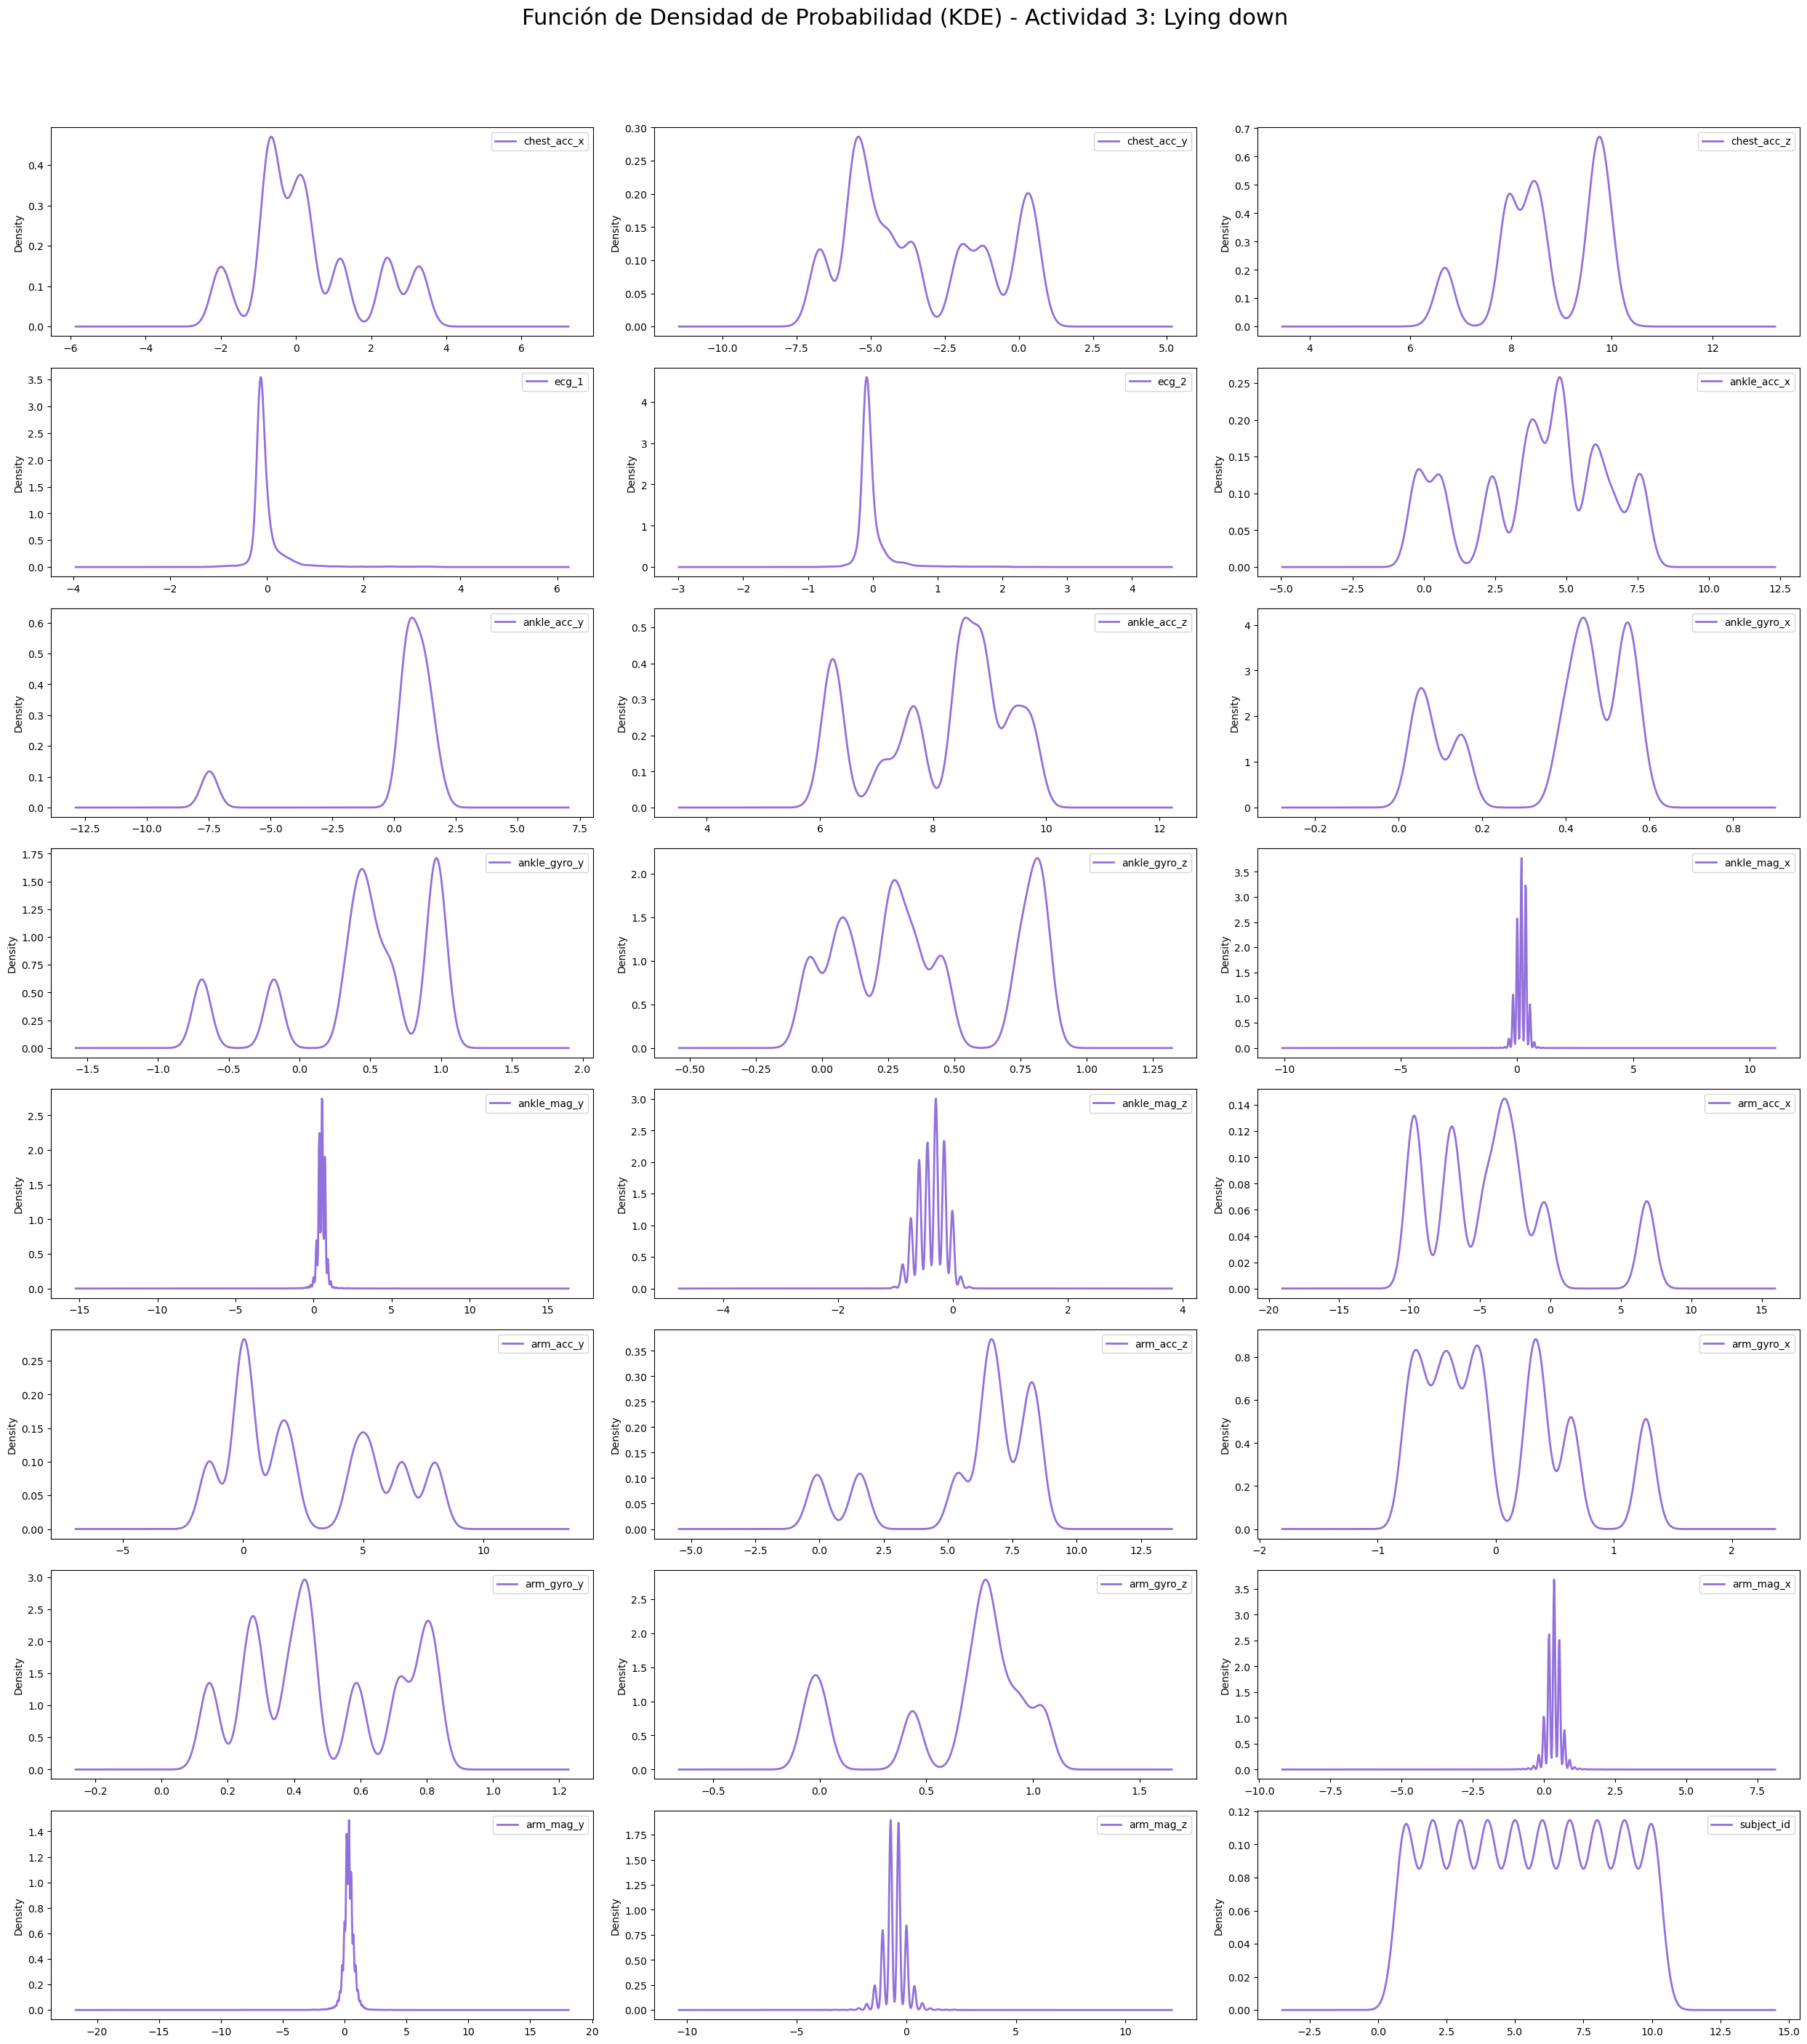

In [9]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

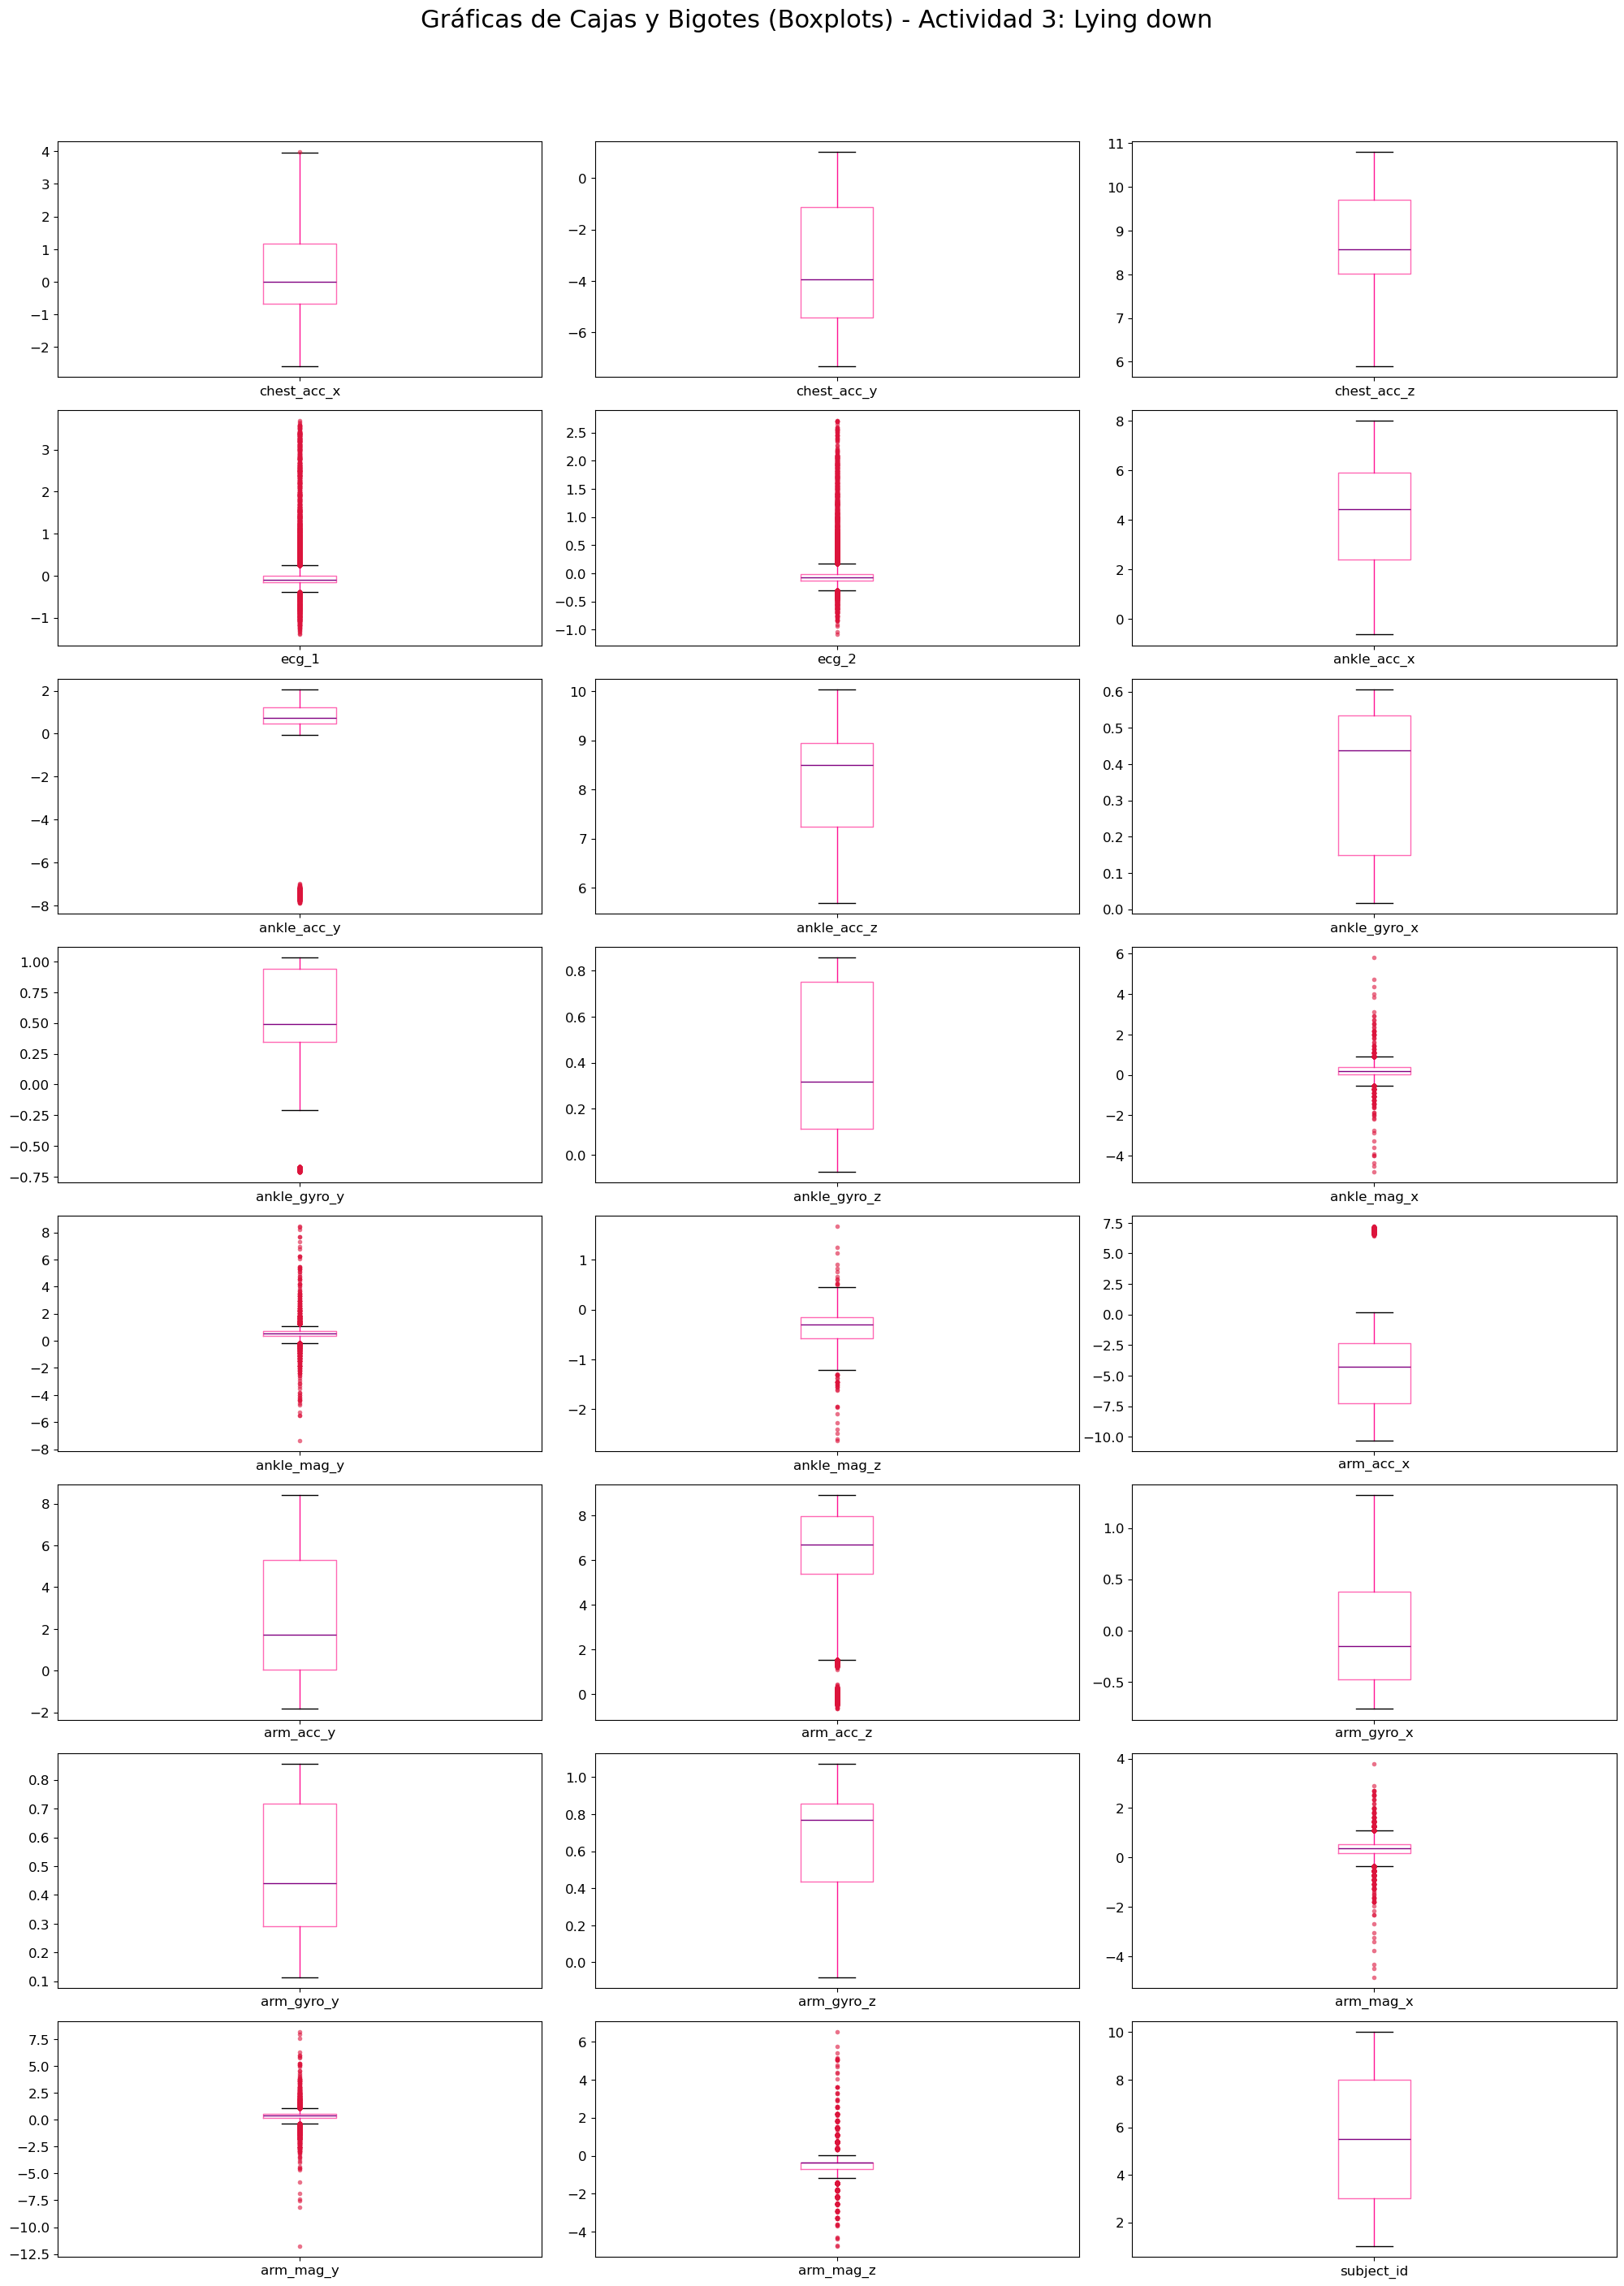

In [10]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

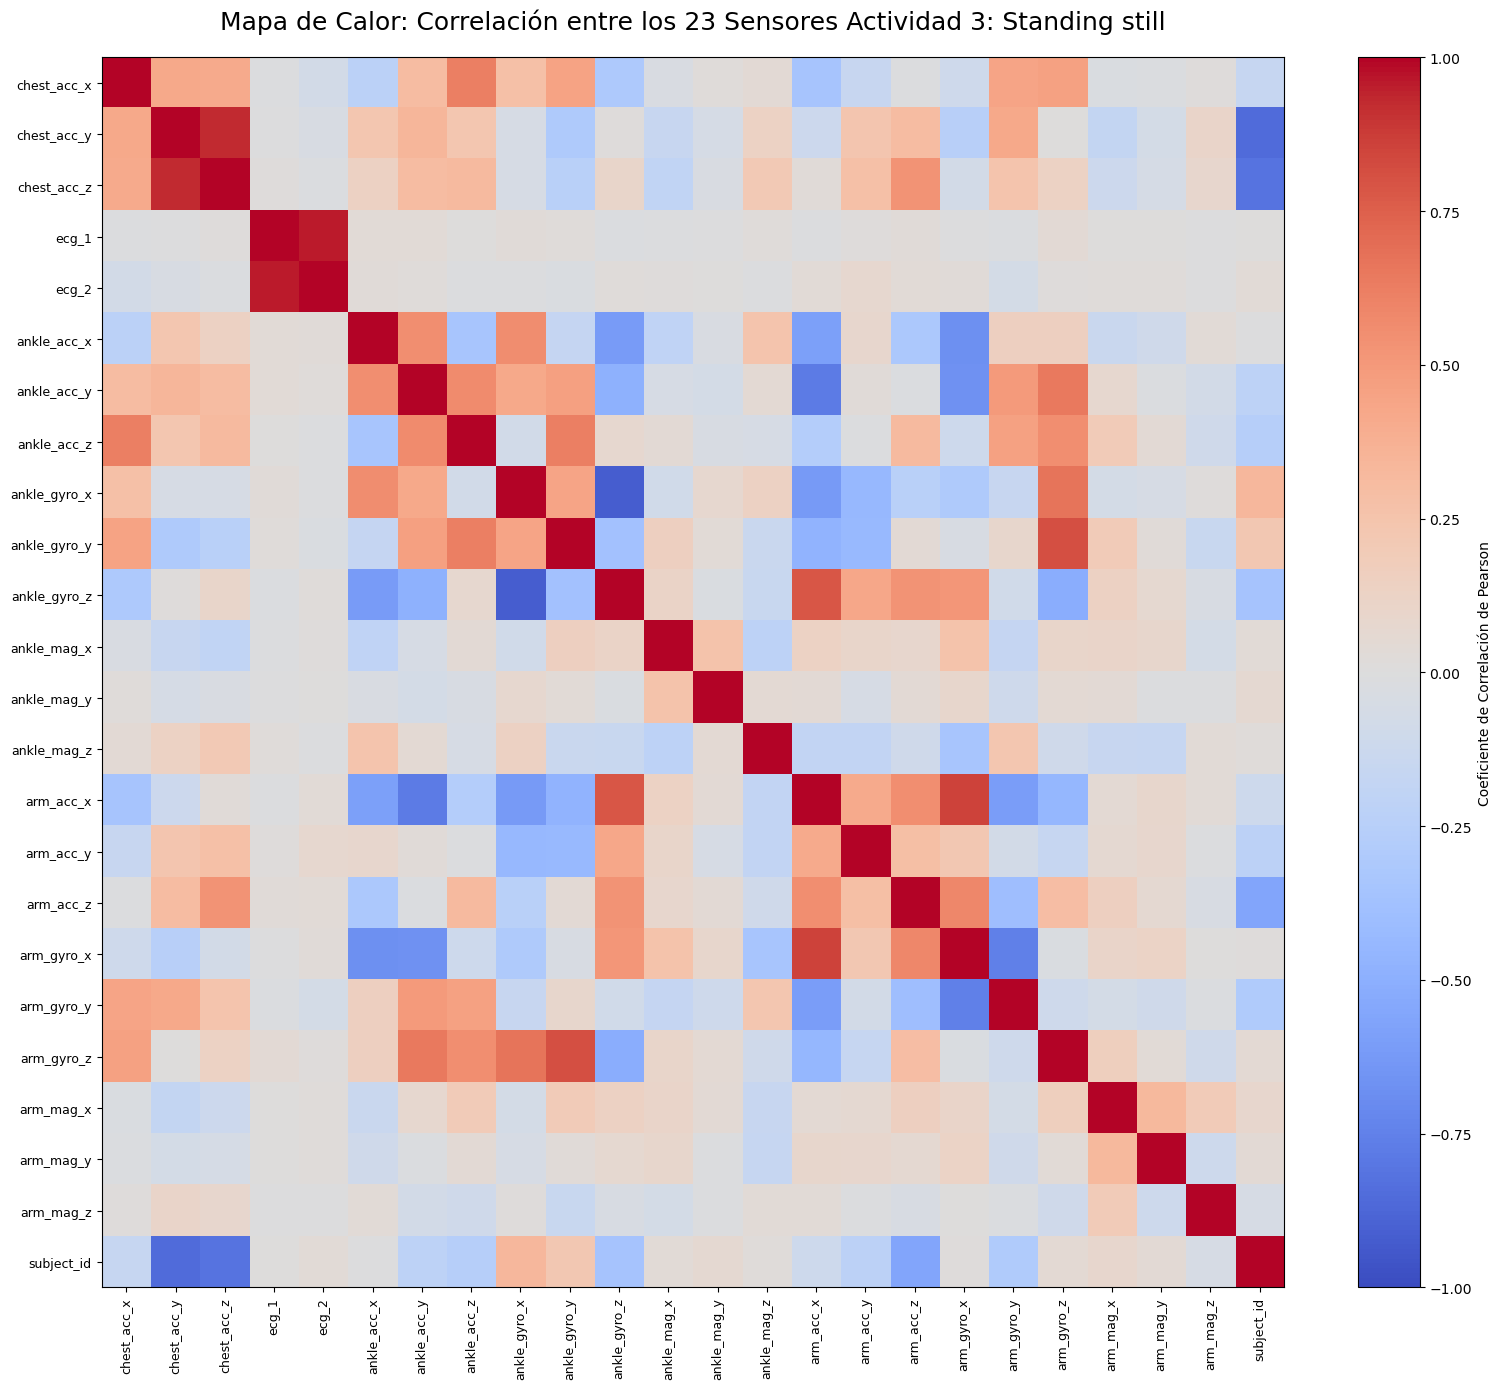

In [11]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

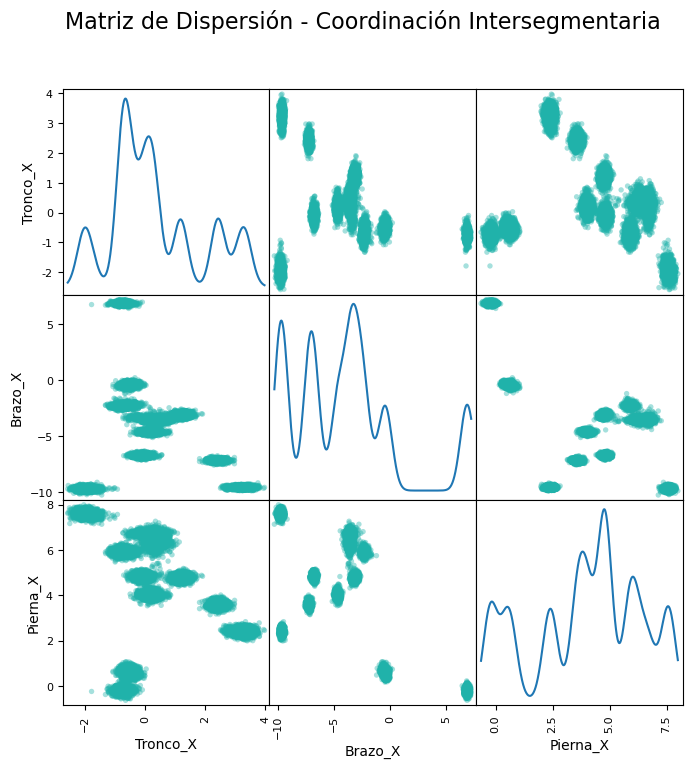

In [12]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

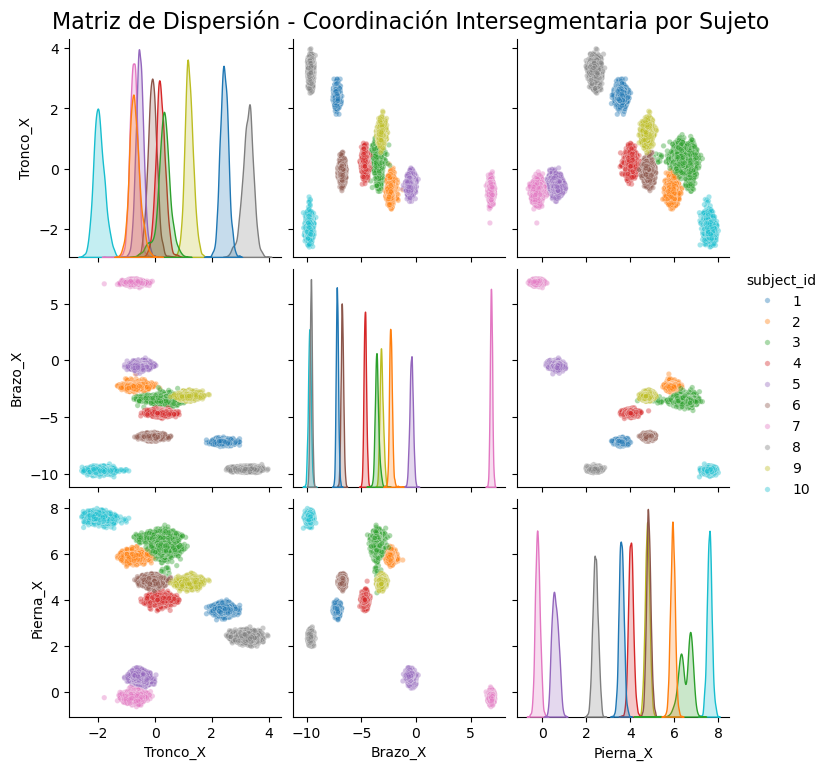

In [13]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()